In [1]:
import os
import sys
import pandas as pd
sys.path.append(os.path.abspath(os.path.join('..')))

train = pd.read_csv("../data/raw/train_BRCpofr.csv.zip", compression="zip")
test = pd.read_csv("../data/raw/test_koRSKBP.csv.zip", compression="zip")

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor

# Building a pipeline for the preprocessing
# 1. Define feature processing pipelines
numeric_features = ['vintage', 'claim_amount']
categorical_features = ['type_of_policy',
                        'marital_status',
                        'qualification',
                        'gender',
                        'area', 'num_policies', 'policy', 'income']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'  # Keep other columns unchanged or wahala for dey
)

# 2. Bundle preprocessing and the XGBRegressor model into a feature pipeline
xgbregressor_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=100, max_depth=6, random_state=42))
])

# 3. Wrap everything to handle your Yeo-Johnson Target automatically!
wrapped_model = TransformedTargetRegressor(
    regressor=xgbregressor_pipeline,
    transformer=PowerTransformer(method='yeo-johnson')
)

In [3]:
from sklearn.model_selection import train_test_split

y = train.drop(columns=['cltv']).set_index('id')
X = train['cltv']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [4]:
# Move the ID column to the index
X_train = train.drop(columns=['cltv']).set_index('id')
y_train = train['cltv']

X_test = test.set_index('id')

# Now run your model pipeline normally
wrapped_model.fit(X_train, y_train)

# When you predict, the output keeps your IDs!
predictions = wrapped_model.predict(X_test)
submission = pd.DataFrame({'cltv_predicted': predictions}, index=X_test.index)

In [5]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Re-run your train_test_split cleanly using your processed features space
X = train.drop(columns=['cltv']).set_index('id')
y = train['cltv']

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 2. Fit the model on the 80% training slice
wrapped_model.fit(X_tr, y_tr)

# 3. Predict on the 20% validation slice
val_predictions = wrapped_model.predict(X_val)

# 4. Calculate accuracy metrics
val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
val_r2 = r2_score(y_val, val_predictions)

print("=== Validation Performance ===")
print(f"R² Score (Variance Explained): {val_r2:.4f}")
print(f"RMSE (Average Error Magnitude): {val_rmse:.2f}")

=== Validation Performance ===
R² Score (Variance Explained): 0.0741
RMSE (Average Error Magnitude): 86075.46


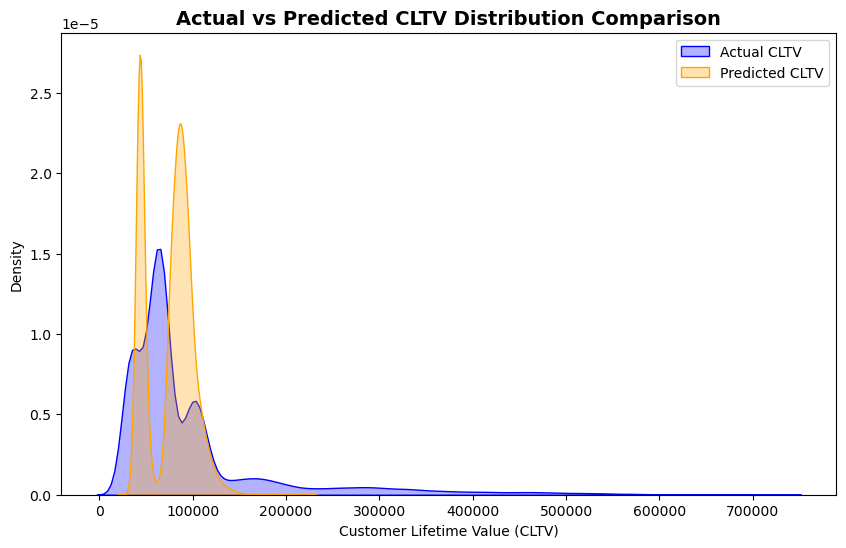

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot actual training target distribution
sns.kdeplot(y_train, label='Actual CLTV', color='blue', fill=True, alpha=0.3)

# Plot validation predicted distribution
sns.kdeplot(val_predictions, label='Predicted CLTV',
            color='orange', fill=True, alpha=0.3)

plt.title("Actual vs Predicted CLTV Distribution Comparison",
          fontsize=14, fontweight='bold')
plt.xlabel("Customer Lifetime Value (CLTV)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [7]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Prepare your data using Method 1 (The Index Trick)
X_train = train.drop(columns=['cltv']).set_index('id')
y_train = train['cltv']

# 1. Define the dictionaries to hold our algorithms
models = {
    'Linear Regression': LinearRegression(),
    'XGBoost Regressor': XGBRegressor(n_estimators=100, max_depth=6, random_state=42)
}

# 2. Loop through each model, wrap it, fit it, and evaluate
for name, model in models.items():

    # Re-create the full pipeline architecture for the current model
    current_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),  # Your ColumnTransformer setup
        ('regressor', model)
    ])

    # Wrap it with the Target Power Transformer
    wrapped_model = TransformedTargetRegressor(
        regressor=current_pipeline,
        transformer=PowerTransformer(method='yeo-johnson')
    )

    # Train the model (automatically handles feature scaling & target normalization)
    wrapped_model.fit(X_train, y_train)

    # Predict on the training set as a baseline check
    train_preds = wrapped_model.predict(X_train)

    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    r2 = r2_score(y_train, train_preds)

    print(f"=== {name} Performance ===")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.4f}\n")

=== Linear Regression Performance ===
Root Mean Squared Error (RMSE): 87549.38
R² Score: 0.0665

=== XGBoost Regressor Performance ===
Root Mean Squared Error (RMSE): 85317.04
R² Score: 0.1135

